In [27]:
import os, glob, random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

Device: cpu


In [29]:
DATASET_DIR = 'E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset'
IMG_SIZE = 224

# discover classes
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print('Classes:', CLASS_NAMES)

# collect paths
image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    for p in imgs:
        image_paths.append(p)
        labels.append(lbl)

# encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [30]:
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.30, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.50, random_state=42
)

print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

Train: 2800  Val: 600  Test: 600


In [31]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [32]:
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transform) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

Extracting features...


100%|██████████| 600/600 [02:29<00:00,  4.02it/s]


In [33]:
class ViTHead(nn.Module):
    def __init__(self, in_features, num_classes=8):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 256)
        self.attn = nn.MultiheadAttention(embed_dim=256, num_heads=4, batch_first=True)
        self.fc2 = nn.Linear(256, num_classes)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = x.unsqueeze(1)  # add sequence dim (batch, seq=1, feat)
        attn_out, _ = self.attn(x, x, x)
        attn_out = attn_out.squeeze(1)
        return self.fc2(attn_out)

in_features = X_train_feats.shape[1]
num_classes = len(CLASS_NAMES)
model_head = ViTHead(in_features, num_classes).to(device)

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_head.parameters(), lr=1e-4)

batch_size = 64
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_feats, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)),
    batch_size=batch_size, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)),
    batch_size=batch_size
)

EPOCHS = 50
PATIENCE = 7
best_val_loss = float("inf")
wait = 0

train_losses, val_losses = [], []

In [35]:
for epoch in range(EPOCHS):
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # --- Validation ---
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            val_loss += criterion(logits, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")


    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model_head.state_dict(), "best_model_exp1a.pth")
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/50  Train Loss: 1.7422  Val Loss: 1.3914
Epoch 2/50  Train Loss: 0.7320  Val Loss: 0.5743
Epoch 3/50  Train Loss: 0.2907  Val Loss: 0.2969
Epoch 4/50  Train Loss: 0.1558  Val Loss: 0.1892
Epoch 5/50  Train Loss: 0.0964  Val Loss: 0.1364
Epoch 6/50  Train Loss: 0.0684  Val Loss: 0.1042
Epoch 7/50  Train Loss: 0.0477  Val Loss: 0.0869
Epoch 8/50  Train Loss: 0.0364  Val Loss: 0.0724
Epoch 9/50  Train Loss: 0.0281  Val Loss: 0.0635
Epoch 10/50  Train Loss: 0.0221  Val Loss: 0.0561
Epoch 11/50  Train Loss: 0.0166  Val Loss: 0.0496
Epoch 12/50  Train Loss: 0.0138  Val Loss: 0.0439
Epoch 13/50  Train Loss: 0.0109  Val Loss: 0.0413
Epoch 14/50  Train Loss: 0.0091  Val Loss: 0.0378
Epoch 15/50  Train Loss: 0.0081  Val Loss: 0.0350
Epoch 16/50  Train Loss: 0.0067  Val Loss: 0.0361
Epoch 17/50  Train Loss: 0.0057  Val Loss: 0.0317
Epoch 18/50  Train Loss: 0.0048  Val Loss: 0.0299
Epoch 19/50  Train Loss: 0.0041  Val Loss: 0.0300
Epoch 20/50  Train Loss: 0.0036  Val Loss: 0.0275
Epoch 21/

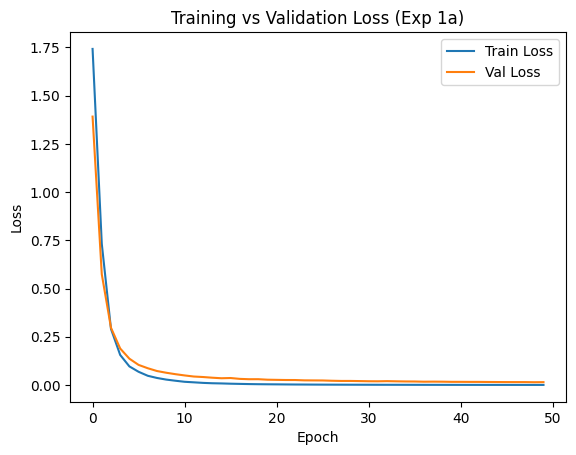

In [36]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Exp 1a)")
plt.legend()
plt.show()


Final Test Metrics (Experiment 1a):
Accuracy  : 0.9933
Precision : 0.9934
Recall    : 0.9933
F1 Score  : 0.9933

Classification Report:
                  precision    recall  f1-score   support

     Anthracnose       1.00      1.00      1.00        75
Bacterial Canker       1.00      1.00      1.00        75
  Cutting Weevil       1.00      1.00      1.00        75
        Die Back       1.00      1.00      1.00        75
      Gall Midge       1.00      1.00      1.00        75
         Healthy       1.00      1.00      1.00        75
  Powdery Mildew       0.99      0.96      0.97        75
     Sooty Mould       0.96      0.99      0.97        75

        accuracy                           0.99       600
       macro avg       0.99      0.99      0.99       600
    weighted avg       0.99      0.99      0.99       600



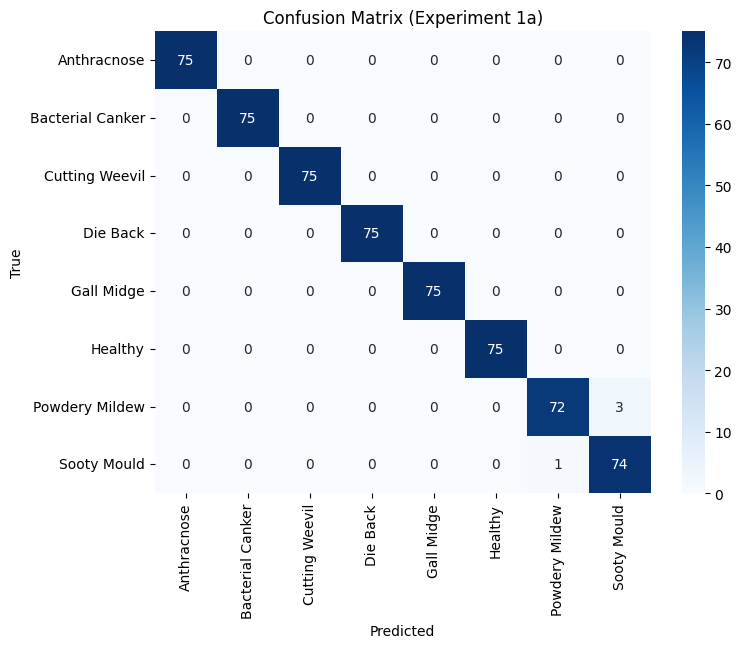

In [37]:
model_head.load_state_dict(torch.load("best_model_exp1a.pth"))
model_head.eval()

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)),
    batch_size=batch_size
)

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model_head(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

y_true, y_pred = np.array(all_labels), np.array(all_preds)
accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

print("\nFinal Test Metrics (Experiment 1a):")
print(f'Accuracy  : {accuracy:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1 Score  : {f1:.4f}')

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Experiment 1a)")
plt.show()